<a href="https://colab.research.google.com/github/naminipla1920-ui/AH2179-Assignments/blob/main/Assignment1_BikeSharing_NataliaNino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [40]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/main/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


## Data exploration

In [41]:
df.shape

(17379, 17)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Remove columns that are no longer needed

In [43]:
df = df.drop(['instant','dteday','casual','registered'], axis=1)

Draw a histogram to show the distribution of bike demand

<Axes: xlabel='cnt', ylabel='Count'>

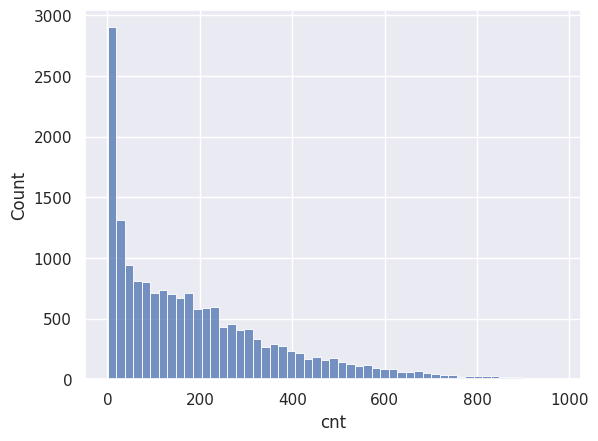

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

sns.histplot(x=df['cnt'])

Find out how much influence input variables have on the values in the bike demand "cnt" column.

In [45]:
corr_matrix = df.corr()
corr_matrix['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
hr,0.394071
yr,0.250495
season,0.178056
mnth,0.120638
windspeed,0.093234
workingday,0.030284
weekday,0.026900


A pairplot is used to explore relationships, correlations, and potential outliers among the continuous climate variables and the target, aiding in feature selection and transformation. Categorical variables are excluded, as scatter plots are less informative for them.

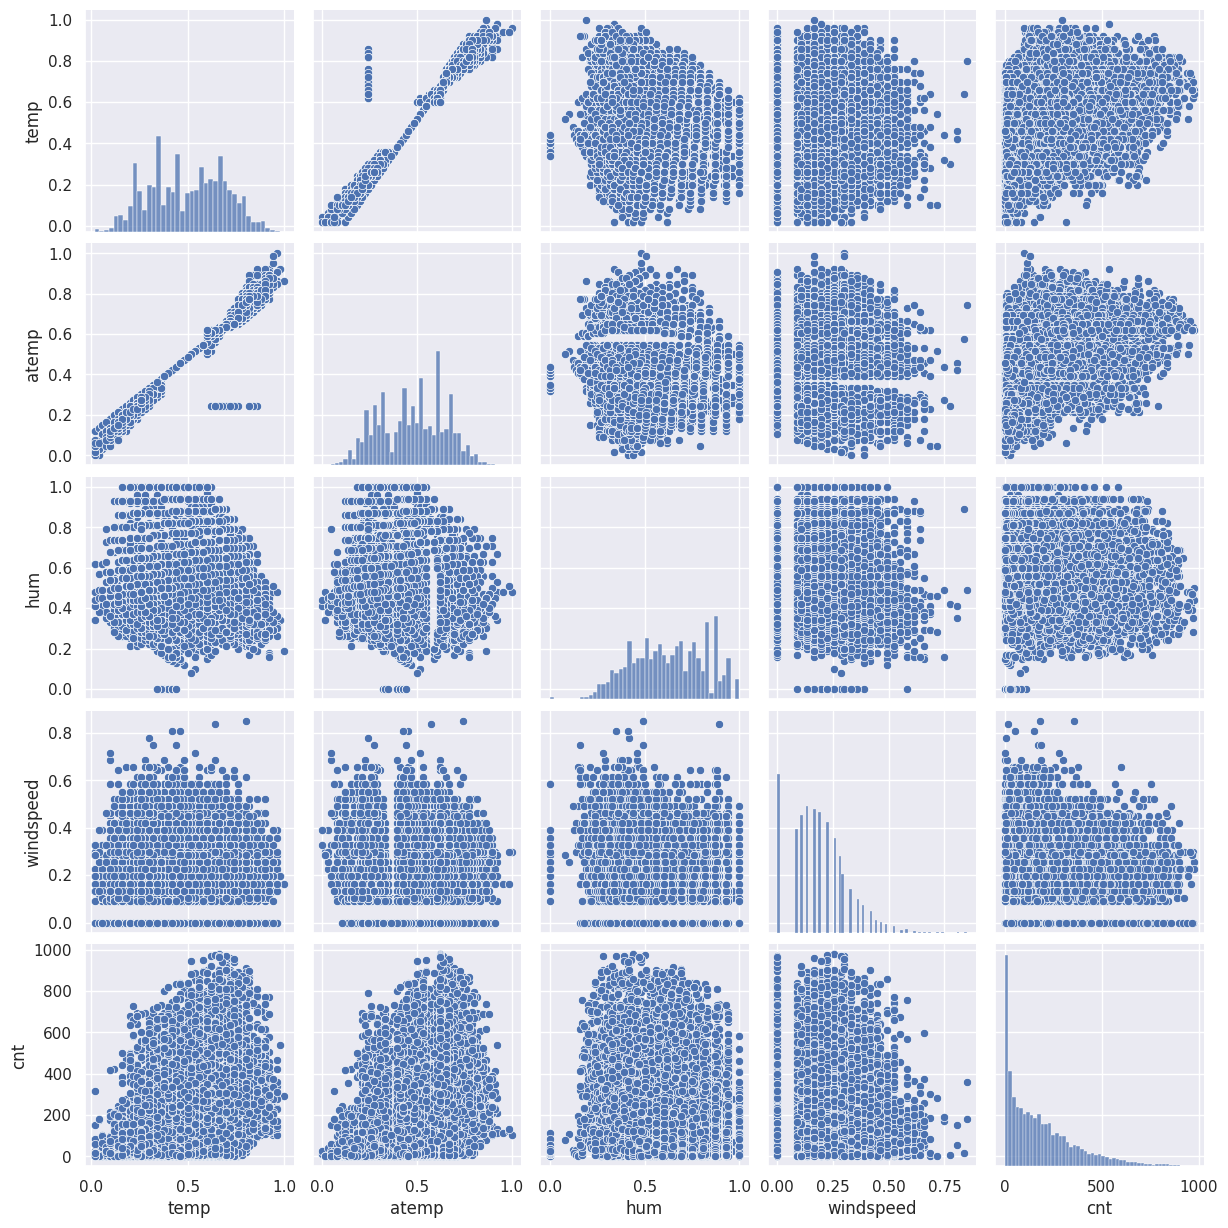

In [46]:
interes_var = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
sns.pairplot(df[interes_var])

## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [47]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Processing / Feature Engineering


One hot encoding for categorical variables: hr, season, weekday, mnth and weathersit

In [48]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical = ['hr', 'season', 'weekday', 'mnth', 'weathersit']

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[categorical])
X_test_cat = ohe.transform(X_test[categorical])

Normalization for continuous variables: temp, atemp, hum and windspeed.

In [49]:
from sklearn.preprocessing import StandardScaler

continuous = ['temp', 'atemp', 'hum', 'windspeed']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[continuous])
X_test_scaled = scaler.transform(X_test[continuous])

Join all the variables (categorical, continuous and binary)

In [50]:
import numpy as np

binary = ['holiday', 'workingday', 'yr']

X_train_prep = np.hstack([X_train_cat, X_train_scaled, X_train[binary].values])
X_test_prep = np.hstack([X_test_cat, X_test_scaled, X_test[binary].values])

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for the model. Use Grid Search to search for the best combination of parameters.

In [51]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.3]
}

grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, verbose=2)
grid_search.fit(X_train_prep, y_train)

best_params = grid_search.best_params_
print("Best Parameters: ", best_params)
print("Best score: ", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=6, n_est

## Train the XGBoost and Linear regression models
Create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [52]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

lin_reg = LinearRegression()
lin_reg.fit(X_train_prep, y_train)

best_xgb = XGBRegressor(learning_rate= 0.3, max_depth= 6, n_estimators= 200, random_state=42)
best_xgb.fit(X_train_prep, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

y_pred_lin = lin_reg.predict(X_test_prep)
y_pred_xgb = best_xgb.predict(X_test_prep)

#Linear Regression metrics
mae = mean_absolute_error(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
r2= r2_score(y_test, y_pred_lin)
rmse = root_mean_squared_error(y_test, y_pred_lin)

print("Linear regression metrics")
print(f"Mean absolute error: {mae}")
print(f"Mean squared error: {mse}")
print(f"R-squared: {r2}")
print(f"RMSE: {rmse}")

#XGBoost metrics
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test,y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)

print("XGBoost metrics")
print(f"Mean absolute error: {mae}")
print(f"Mean squared error: {mse}")
print(f"R-squared: {r2}")
print(f"RMSE: {rmse}")


Linear regression metrics
Mean absolute error: 74.10515899029582
Mean squared error: 10089.38811515939
R-squared: 0.681375112801918
RMSE: 100.44594623557185
XGBoost metrics
Mean absolute error: 30.750757793026736
Mean squared error: 2304.4581229209816
R-squared: 0.9272247532667345
RMSE: 48.00477187656433


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

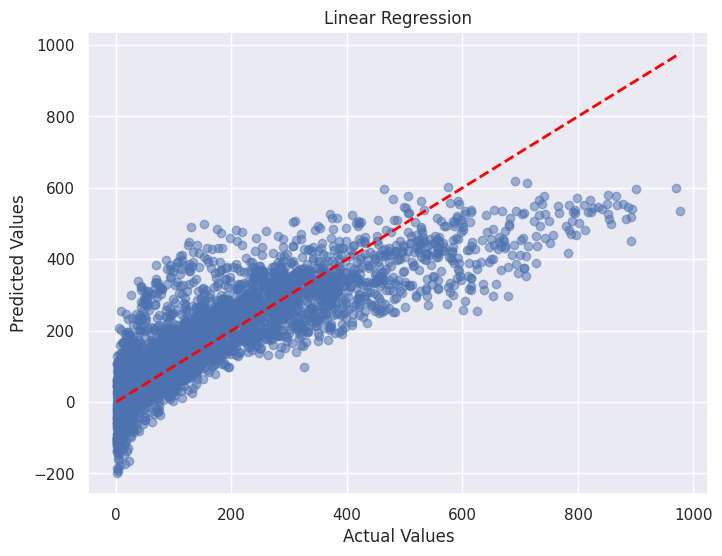

<function matplotlib.pyplot.show(close=None, block=None)>

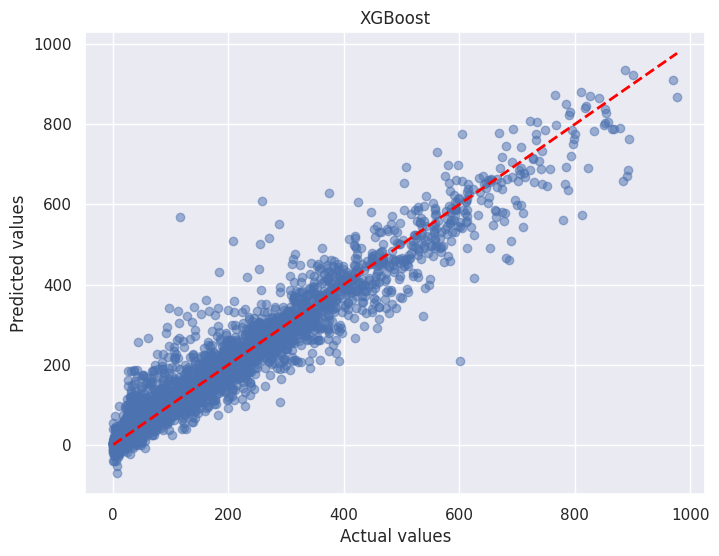

In [54]:
import matplotlib.pyplot as plt

#Linear Regression
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lin, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression")

plt.plot([min(y_test), max(y_test)],[min(y_test),max(y_test)], linestyle='--', color='red', lw=2)

plt.show()

#XGBoost
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)

plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("XGBoost")

plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

plt.show